## Quarta etapa

Em quarta_etapa.ipynb, utilizaremos dos registros que filtramos (ou não) em terceira_etapa.ipynb, e faremos a filtragem dos códigos de barras. Cada exsicata devem ser fornecidas um código de barra para a sua identificação pessoal. Se utilizarmos exsicatas sem códigos de barra não poderemos identificá-la, se necessário, futuramente. Portanto, removeremos todos os registros que não possuem um código de barras.

Seguindo a mesma convenção da etapa anterior, o nome do novo campo será barcode_att, pois o campo original é barcode.

In [4]:
from bibliotecas import *

specieslink, db_config = configurar()

In [6]:
campo_input = input("informe o nome que voce deseja que o novo campo tenha (não crie o campo manualmente quando executando pelo pipeline!)").strip()
original_input = "barcode"
table = "registros_biodiversidade"

try:
    sql = f"ALTER TABLE {table} ADD COLUMN {campo_input} TEXT"

    cursor.execute(sql)
    conn.commit()

    print(f"campo '{campo_input}' criado com sucesso na tabela '{table}'")

    cursor.close()
    conn.close()  
except Exception as e:
    print(f"campo '{campo_input}' já existe ou erro ao criar: {e}")

conn = mysql_conn.connect(**db_config)
cursor = conn.cursor()

sql = f"""
UPDATE {table}
SET {campo_input} = {original_input}
WHERE {original_input} IS NOT NULL
"""

cursor.execute(sql)
conn.commit()

cursor.close()
conn.close()


campo 'barcode_att' criado com sucesso na tabela 'registros_biodiversidade'


In [7]:
conn = mysql_conn.connect(**db_config)
cursor = conn.cursor()

sql = """
SELECT
    COUNT(*) AS total_registros,
    SUM(country_att IS NOT NULL) AS com_country,
    SUM(country_att IS NOT NULL AND stateprovince_att IS NOT NULL) AS com_country_e_state,
    SUM(country_att IS NOT NULL AND stateprovince_att IS NOT NULL AND barcode_att IS NOT NULL) as com_country_state_e_barcode
FROM registros_biodiversidade
"""

cursor.execute(sql)
total_registros, registros_country, registros_country_state, registros_country_state_barcode = cursor.fetchone()

cursor.close()
conn.close()

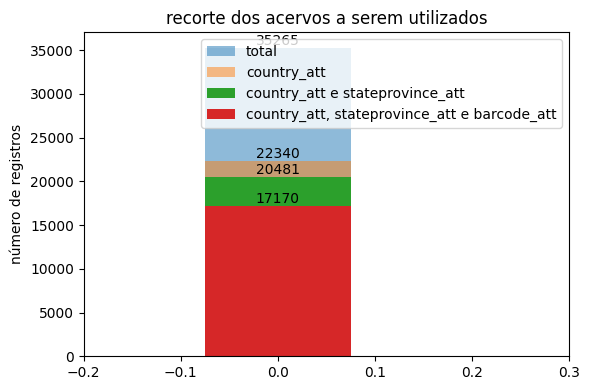

In [8]:
plt.figure(figsize=(6, 4))

x = [0]

plt.bar(
    x,
    [total_registros],
    alpha=0.5,
    width=0.15,
    label='total'
)

plt.bar(
    x,
    [registros_country],
    alpha=0.5,
    width=0.15,
    label='country_att'
)

plt.bar(
    x,
    [registros_country_state],
    width=0.15,
    label='country_att e stateprovince_att'
)

plt.bar(
    x,
    [registros_country_state_barcode],
    width=0.15,
    label='country_att, stateprovince_att e barcode_att'
)

plt.xlim(-0.2, 0.3)
plt.ylabel('número de registros')
plt.title('recorte dos acervos a serem utilizados')
plt.legend()

plt.text(0, total_registros, str(total_registros), ha='center', va='bottom')
plt.text(0, registros_country, str(registros_country), ha='center', va='bottom')
plt.text(0, registros_country_state, str(registros_country_state), ha='center', va='bottom')
plt.text(0, registros_country_state_barcode, str(registros_country_state_barcode), ha='center', va='bottom')

plt.tight_layout()
plt.show()